# BINF TP6 - Alignements multiples et scores

Dans ce TP nous allons manipuler les concepts plus avancés d'alignement.

#Exercice 0 : Echauffement

Q1. Calculer le profil de l'alignement suivant:
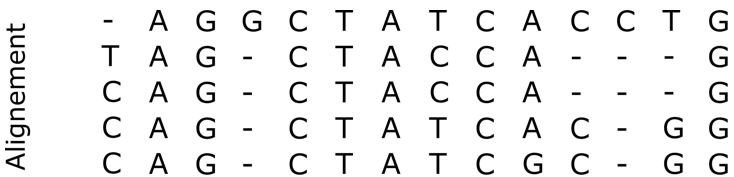

| | | | | | | | | | | | | | | |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **A** |     | 1 |   |     |   |   | 1 |     |   | 0.8 |     |     |     |   |
| **T** | 0.2 |   |   |     |   | 1 |   | 0.6 |   |     |     |     | 0.2 |   |
| **G** |     |   | 1 | 0.2 |   |   |   |     |   | 0.2 |     |     | 0.4 | 1 |
| **C** | 0.6 |   |   |     | 1 |   |   | 0.4 | 1 |     | 0.6 | 0.2 |     |   |
| **-** | 0.2 |   |   | 0.8 |   |   |   |     |   |     | 0.4 | 0.8 | 0.4 |   |

Q2. Calculez la matrice de substitution entre profils $\Sigma(P_A, P_B)$, étant donné les deux profils et la matrice de substitution suivante:
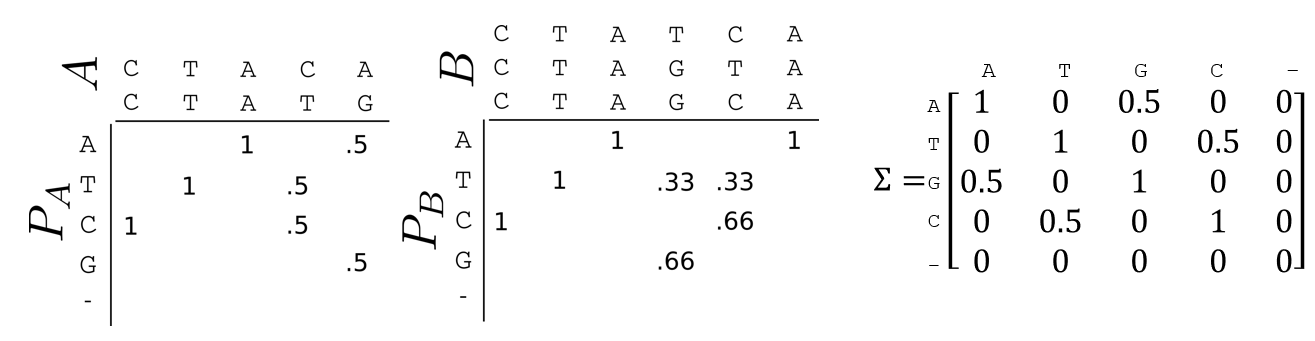

|       | CCC   | TTT   | AAA   | TGG   | CTC   | AAA   |   
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
|CC     | 1     | 0.5    |       | 0.16  | 0.83  |       |
|TT     | 0.5   | 1     |       | 0.33  | 0.66  |       |
|AA     |       |       | 1     | 0.33  |       | 1     |
|CT     | 0.75  | 0.75  |       | 0.25  | 0.75  |       |
|AG     |       |       | 0.7   |       |       | 0.75  |

Q3. En utilisant $\Sigma(P_A,P_B)$ et une fonction d'évaluation des trous linéaire $\gamma(n) = 0.5 \times n$ alignez $P_A$ et $P_B$ en utilisant l'algorithme de Smith-Waterman.

|       |       |       |       |       |       |       |   
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **A1**| C     | T     | A     | T     | C     | A     |
| **A2**| C     | T     | A     | G     | T     | A     |
| **A3**| C     | T     | A     | G     | C     | A     |
| **B1**| C     | T     | A     | -     | C     | A     |
| **B2**| C     | T     | A     | -     | T     | G     |

# Exercice 1 : Distribution des scores d’alignement pour des séquences aléatoires

Pour tester si un alignement reflète une réelle similarité biologique, on va évaluer la distribution des scores d’alignement pour des paires de séquences aléatoires.

Q1. En considérant deux séquences aléatoires de même taille N, où chaque nucléotide apparaît avec une probabilité uniforme de ¼, calculer le score moyen attendu pour une superposition sans trou dans le cas où une identité vaut +1 et une différence vaut 0.

En considérant $p_A = p_T = p_G = p_C = 1/4$ et que les différentes positions de chacune des deux séquence sont indépendantes alors on a une probabilité $p_A^2 + p_T^2 + p_G^2 + p_C^2 = 4/16 = 1/4$ d'avoir une correspondance entre les caractères des deux séquences à chaque position. Si on choisi +1
par correspondances alors pour deux séquences de taille $N$ on aura donc en moyenne un score de $N$/4

Q2. La question précédente peut se resoudre analytiquement car on ne considère pas de trou. Pour étendre le résultat precedent à un alignement avec trous, on va se baser sur la simulation de séquences aleatoires.

Générez $R=100$ paires de séquences aléatoires  de tailles $N=100$ nucléotides avec des probabilitées uniformes d'apparition de nucléotides $p_A = p_T = p_G = p_C = $ ¼.

In [ ]:
!pip install biopython

In [ ]:
import numpy.random as rnd

def genseq(R, N):
  return [("".join(["ATGC"[k] for k in rnd.randint(0, 4, N)]),
           "".join(["ATGC"[k] for k in rnd.randint(0, 4, N)])) for k in range(N)]
ss = genseq(100, 100)

Q3. Calculer le score de superposition entre chaque paire de séquences générée à la question précédente par
1. Score de superposition sans trou avec +1 pour une identité et +0 pour une différence ;
2. Smith-Waterman avec +1 pour une identité, -0.5 pour une différence et une fonction d'évaluation des trous linéaire avec coefficient d'extension -0.5.

Pour calculer le score d'alignement de Smith-Waterman, vous pouvez utiliser la bibliothèque biopython: https://biopython.org/docs/dev/Tutorial/chapter_pairwise.html

In [ ]:
import numpy as np
sigma = np.eye(4,4)
cmap = {"A": 0, "T": 1, "G": 2, "C": 3}

from Bio import Align
aligner = Align.PairwiseAligner(mode="local", open_gap_score=0, extend_gap_score=-0.5,
                                match_score=1, mismatch_score=-0.5)

res_sw = []
res_nogap = []
for s1,s2 in ss:
  res_nogap.append(sum([sigma[cmap[s1[i]], cmap[s2[i]]] for i in range(len(s1))]))
  res_sw.append(aligner.align(s1, s2)[0].score)


Q4. Affichez un violoinplot des scores obtenus avec sur le même plot le score SW et celui d'alignement sans trou.

In [ ]:
from matplotlib import pyplot as plt

plt.figure()
plt.violinplot([res_nogap, res_sw])
plt.ylabel('Score')
plt.xticks([1, 2], ['No gap', 'SW'])

Q4. Qu'observez-vous ?

Comme attendu, le score SW est plus élevé que le score sans trou. Les scores SW sont élevés en considérant que le max score = 100.

Q5. Quelle conclusion peut-on en tirer sur la significativité d'un alignement ?

Ces scores élevés indiquent qu'il faut faire attention à ce qu'on considère comme un réel alignement vs du bruit.

Q6. En quoi celà fait-il le lien avec les paramètres de l'algorithme BLAST ?

Déterminer les alignements statistiquement significatifs est une partie importante de la méthode BLAST. Pour celà, il faut prendre en compte les tailles des séquences et le schéma d'évaluation utilisé.